In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
dataset = pd.read_csv("C:/Users/user/OneDrive/Documents/Learn AI/ML_Projects/customer-segmentation/dataset/online_retail.csv")

In [3]:
dataset.shape

(541909, 8)

In [4]:
dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
dataset.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Handle Null Values

In [6]:
dataset.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
dataset = dataset.dropna(subset=["CustomerID"])
dataset = dataset.dropna(subset=["Description"])

In [8]:
dataset.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
dataset.shape


(406829, 8)

In [10]:
#remove negative quantity
dataset = dataset[dataset["Quantity"] > 0]

#remove negative price
dataset = dataset[dataset["UnitPrice"] > 0]

# convert date
dataset["InvoiceDate"] = pd.to_datetime(dataset["InvoiceDate"])

In [11]:
#create total price

dataset["TotalPrice"] = dataset["Quantity"] * dataset["UnitPrice"]

In [12]:
dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


RFM =

R = Recency (How recent customer bought → “When did they last visit?”)

F = Frequency (How often they buy → “How often they come?”)

M = Monetary (How much they spend)

In [13]:
snapshot_date = dataset["InvoiceDate"].max() + pd.Timedelta(days=1)

In [14]:
rfm = dataset.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

In [15]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


Recency vs Monetary

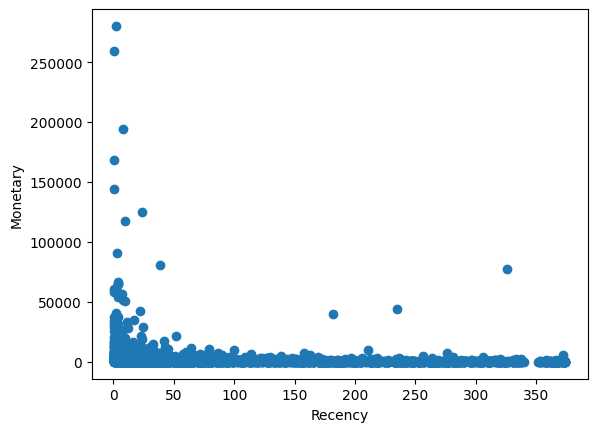

In [16]:
plt.scatter(rfm["Recency"], rfm["Monetary"])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

Recency vs Frequency

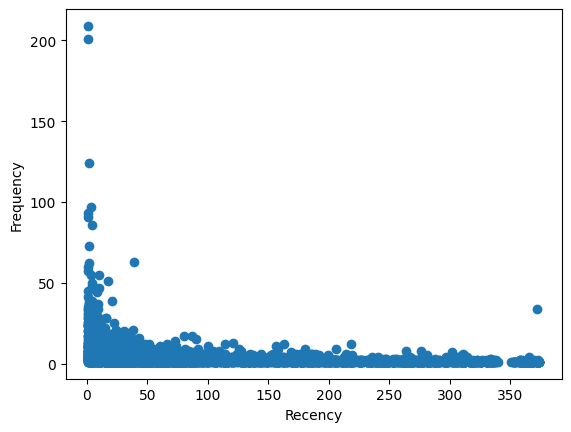

In [17]:
plt.scatter(rfm["Recency"], rfm["Frequency"])
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.show()

Frequency vs Monetary

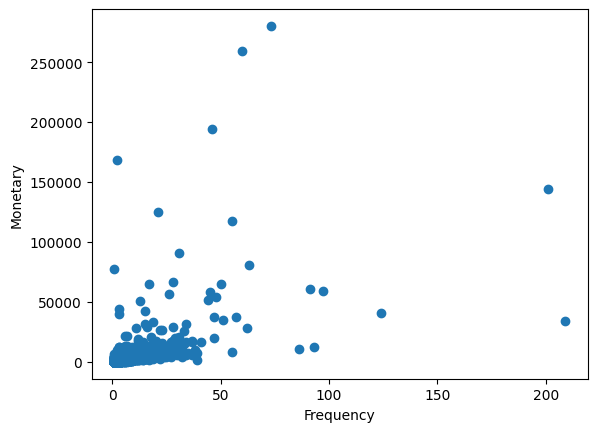

In [18]:
plt.scatter(rfm["Frequency"], rfm["Monetary"])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

all in one 3Dplot

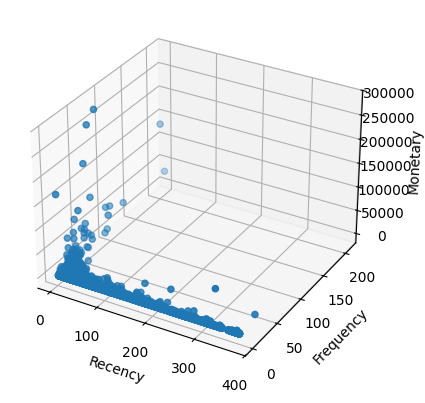

In [19]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm["Recency"], rfm["Frequency"], rfm["Monetary"])
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.show()

Normalize data

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [21]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


Visualize scale data

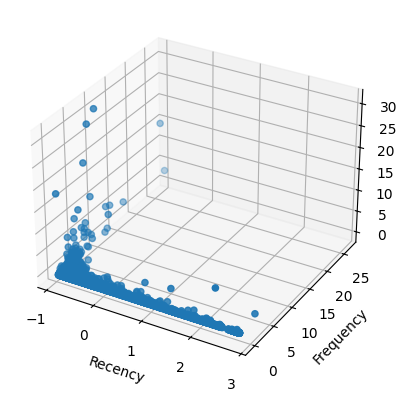

In [22]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_scaled["Recency"], rfm_scaled["Frequency"], rfm_scaled["Monetary"])
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.show()

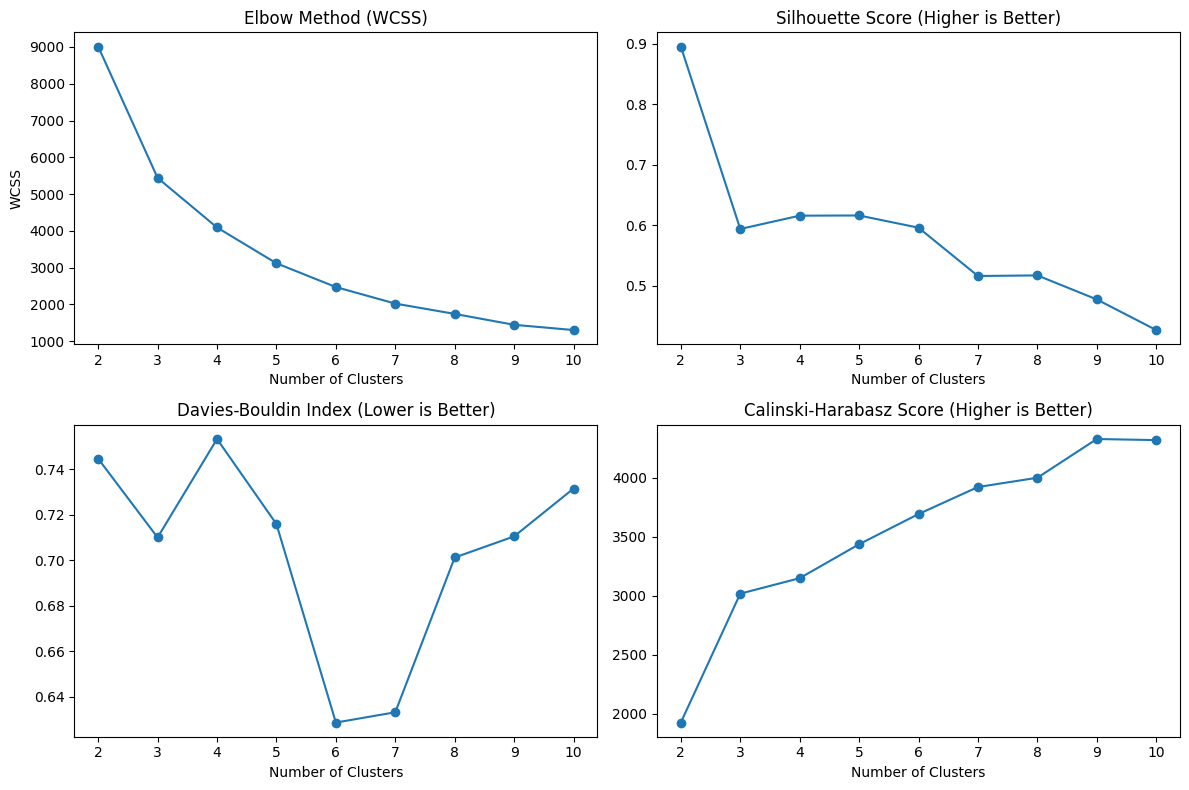

In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

wcss = []
silhouette_scores = []
db_scores = []
ch_scores = []

K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    wcss.append(kmeans.inertia_)

    # Metrics
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))
    ch_scores.append(calinski_harabasz_score(rfm_scaled, labels))


plt.figure(figsize=(12, 8))

# Elbow (WCSS)
plt.subplot(2, 2, 1)
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

# Silhouette Score
plt.subplot(2, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score (Higher is Better)')
plt.xlabel('Number of Clusters')

# Davies-Bouldin
plt.subplot(2, 2, 3)
plt.plot(K_range, db_scores, marker='o')
plt.title('Davies-Bouldin Index (Lower is Better)')
plt.xlabel('Number of Clusters')

# Calinski-Harabasz
plt.subplot(2, 2, 4)
plt.plot(K_range, ch_scores, marker='o')
plt.title('Calinski-Harabasz Score (Higher is Better)')
plt.xlabel('Number of Clusters')

plt.tight_layout()
plt.show()

Optimum Number of Clusters = 5

Training the k-Means Clustering Model

In [24]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)

pred = kmeans.fit_predict(rfm_scaled)

print(pred[100:500])

[2 0 0 2 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 1
 1 0 0 2 0 0 1 1 0 0 0 0 1 0 1 2 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 2 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 2 0 0 2 2 2 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 2 0 0 0 0 0 0 1 0 0 2 0 0 0 0 1 0 0 0 0 2 1 1 1 1 1 1 0
 0 0 2 0 3 0 0 0 2 1 1 0 2 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0
 0 1 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 2 0 2 0 0 0 1
 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 2 1
 0 0 1 0 0 0 0 1 0 0 0 0 2 1 0 0 0 0 1 0 2 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 3 1 1 1 0 0 1 0 0 0 1 2 0 0 0 0 0 0 1]


In [25]:
rfm_scaled['Cluster'] =pred
rfm_scaled.head()

,Recency,Frequency,Monetary,Cluster
0,2.334574,-0.425097,8.358668,2
1,-0.905340,0.354417,0.250966,0
2,-0.175360,-0.035340,-0.028596,0
3,-0.735345,-0.425097,-0.033012,0
4,2.174578,-0.425097,-0.191347,1


In [26]:
c1 = rfm_scaled[rfm_scaled['Cluster'] == 0]
c2 = rfm_scaled[rfm_scaled['Cluster'] == 1]
c3 = rfm_scaled[rfm_scaled['Cluster'] == 2]
c4 = rfm_scaled[rfm_scaled['Cluster'] == 3]
c5 = rfm_scaled[rfm_scaled['Cluster'] == 4]


In [27]:
c1.head()

,Recency,Frequency,Monetary,Cluster
1,-0.905340,0.354417,0.250966,0
2,-0.175360,-0.035340,-0.028596,0
3,-0.735345,-0.425097,-0.033012,0
5,-0.565349,0.484336,0.050263,0
9,-0.695346,-0.165259,0.084240,0


In [28]:
c2.head()


,Recency,Frequency,Monetary,Cluster
4,2.174578,-0.425097,-0.191347,1
6,1.114606,-0.425097,-0.218650,1
7,1.394599,-0.425097,-0.108461,1
8,1.214604,-0.425097,-0.177440,1
14,1.944584,-0.425097,-0.207424,1


In [29]:
c3.head()


,Recency,Frequency,Monetary,Cluster
0,2.334574,-0.425097,8.358668,2
69,-0.565349,1.393768,0.493223,2
75,-0.905340,1.783525,0.322328,2
100,-0.905340,3.342551,1.977014,2
103,-0.755344,1.783525,0.592057,2


In [30]:
c4.head()


,Recency,Frequency,Monetary,Cluster
326,-0.915340,26.598031,3.523006,3
481,-0.885341,10.618009,1.016405,3
562,-0.895341,12.047116,6.316237,3
1661,-0.915340,11.527441,1.123961,3
1879,-0.915340,25.558680,15.773001,3


In [31]:
c5.head()

,Recency,Frequency,Monetary,Cluster
55,-0.685346,2.173281,13.669071,4
1333,-0.825342,6.590523,12.830760,4
1689,-0.905340,8.929063,30.946344,4
3008,-0.915340,-0.295178,18.515202,4
3728,-0.845342,5.421253,21.416596,4


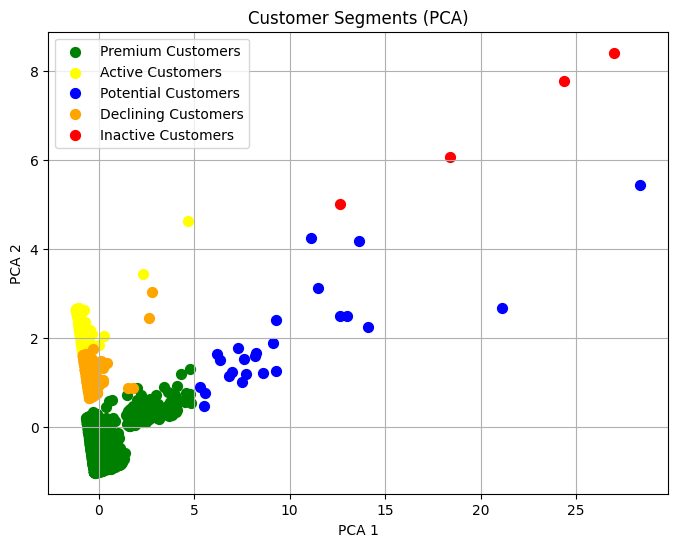

In [32]:
# Step 1: Fit model
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Step 2: PCA (ADD THIS 🔥)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(rfm_scaled)

# Step 3: Define segment names
cluster_names = {
    0: "Premium Customers",
    1: "Active Customers",
    2: "Potential Customers",
    3: "Declining Customers",
    4: "Inactive Customers"
}

# Step 4: Plot
plt.figure(figsize=(8,6))

colors = ['green', 'yellow', 'blue', 'orange', 'red']

for i in range(rfm['Cluster'].nunique()):
    plt.scatter(
        reduced[rfm['Cluster'] == i, 0],
        reduced[rfm['Cluster'] == i, 1],
        color=colors[i],
        label=cluster_names[i],
        s=50
    )

plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

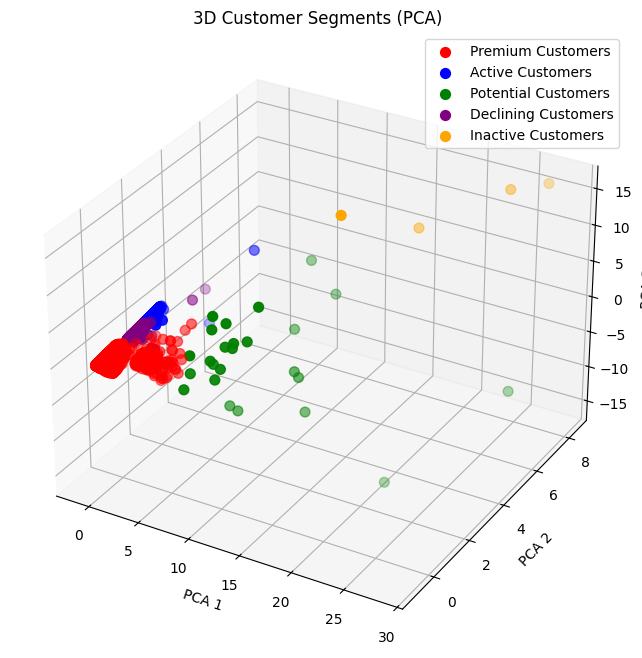

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: PCA
pca = PCA(n_components=3)
reduced = pca.fit_transform(rfm_scaled)

# Step 2: Cluster names
cluster_names = {
    0: "Premium Customers",
    1: "Active Customers",
    2: "Potential Customers",
    3: "Declining Customers",
    4: "Inactive Customers"
}

# Step 3: Colors
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Step 4: Create 3D plot FIRST
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Step 5: Plot clusters
for i in range(rfm['Cluster'].nunique()):
    ax.scatter(
        reduced[rfm['Cluster'] == i, 0],
        reduced[rfm['Cluster'] == i, 1],
        reduced[rfm['Cluster'] == i, 2],
        color=colors[i],
        label=cluster_names[i],   # ✅ use names
        s=50
    )

# Step 6: Labels
ax.set_title("3D Customer Segments (PCA)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

ax.legend()

plt.show()

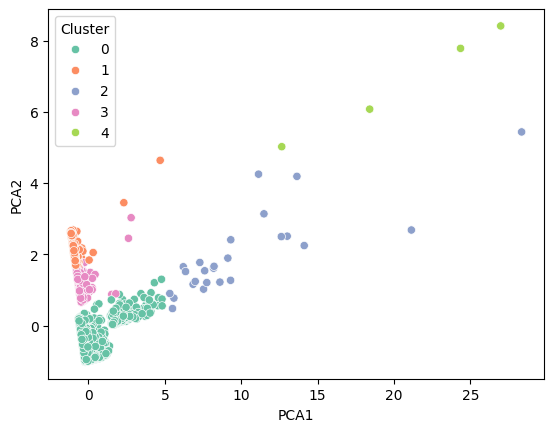

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = pca_data[:,0]
rfm["PCA2"] = pca_data[:,1]
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster", palette="Set2")
plt.show()